In [1]:
import sys
sys.path.append('..')

import os

import numpy as np
import pandas as pd
import scipy as sp

# import tensorflow as tf
# from tensorflow.keras import Model, Input, losses, layers, optimizers

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
# from sklearn.metrics import accuracy_score
# from sklearn.metrics import f1_score

from matplotlib import pyplot as plt
# from matplotlib.colors import BoundaryNorm
# import seaborn as sns

# import itertools
from tqdm.auto import trange, tqdm

from pathlib import Path

import toml

# from src.datasets import adults
# from src.evaluation import data_benchmark
# from src.models import vae_keras
# from src.datasets import adults#, dataset_utils

# print(tf.config.list_physical_devices('GPU'))
# tf.debugging.set_log_device_placement(True)

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# import tensorflow as tf
# for gpu in tf.config.list_physical_devices('GPU'):
#     tf.config.experimental.set_memory_growth(gpu, True)

In [2]:
eps_vals = [2, 3, 4, 5, 6, 7, 8, 9, 10]

def get_stats(vals):
    lrs = []
    norms = []
    noise_multiplicities = []
    for v in vals:
        with open('../exp/wilt/wilt_dp_eps_' + str(v) + '_best/config.toml', 'r') as file:
            config = toml.load(file)
        lrs.append(config['train']['main']['lr'])
        norms.append(config['train']['main']['max_grad_norm'])
        noise_multiplicities.append(config['train']['main']['noise_multiplicity'])
        
    return lrs, norms, noise_multiplicities

lrs, norms, noise_multiplicities = get_stats(eps_vals)
df = pd.DataFrame([lrs, norms, noise_multiplicities], index=['lr', 'max_grad_norm', 'noise_multiplicity'], columns=eps_vals)

print(df.to_string(line_width=10000))

                           2          3          4          5          6          7          8          9          10
lr                   0.004364   0.004364   0.004364   0.004364   0.004364   0.004364   0.004364   0.004778   0.004364
max_grad_norm        0.461650   0.461650   0.461650   0.461650   0.461650   0.461650   0.461650   0.587001   0.461650
noise_multiplicity  69.000000  69.000000  71.000000  71.000000  69.000000  71.000000  97.000000  16.000000  69.000000


In [3]:

                           2          3          4          5          6          7          8          9          10
lr                   0.004364   0.004364   0.004364   0.004364   0.004364   0.004364   0.004364   0.004778   0.004364
max_grad_norm        0.461650   0.461650   0.461650   0.461650   0.461650   0.461650   0.461650   0.487001   0.461650
noise_multiplicity  69.000000  69.000000  71.000000  71.000000  69.000000  71.000000  97.000000  71.000000  71.000000

                           2          3          4          5          6          7          8          9          10         25         50
lr                   0.004364   0.004364   0.004364   0.004364   0.004364   0.004364   0.004364   0.004778   0.004364   0.004364   0.004364
max_grad_norm        0.461650   0.461650   0.461650   0.461650   0.461650   0.461650   0.461650   0.487001   0.461650   0.461650   0.461650
noise_multiplicity  69.000000  69.000000  71.000000  71.000000  69.000000  71.000000  97.000000  16.000000  46.000000  29.000000  17.000000
                          2          3          4          5          6          7          8          9          10         25         50        75         100
lr                   0.004364   0.004364   0.004364   0.004364   0.004364   0.004364   0.004364   0.004778   0.004364   0.004364   0.004364  0.004364   0.004006
max_grad_norm        0.461650   0.461650   0.461650   0.461650   0.461650   0.461650   0.461650   0.487001   0.461650   0.461650   0.461650  0.461650   0.638056
noise_multiplicity  69.000000  69.000000  71.000000  71.000000  71.000000  56.000000  97.000000  16.000000  46.000000  29.000000  17.000000  4.000000  12.000000
                          2          3          4          5          6          7          8          9          10         25         50        75         100
lr                   0.004364   0.004364   0.004364   0.004364   0.004364   0.004364   0.004364   0.004778   0.004364   0.004364   0.004364  0.004364   0.004006
max_grad_norm        0.461650   0.461650   0.461650   0.461650   0.461650   0.461650   0.461650   0.487001   0.461650   0.461650   0.461650  0.461650   0.638056
noise_multiplicity  69.000000  69.000000  71.000000  96.000000  71.000000  56.000000  97.000000  16.000000  46.000000  29.000000  17.000000  4.000000  12.000000

                        5          7          8          9          10         25         50        75         100
lr                    0.004364   0.004364   0.004364   0.004364   0.004364   0.004364   0.004364  0.004364   0.004006
max_grad_norm         0.461650   0.461650   0.461650   0.461650   0.461650   0.461650   0.461650  0.461650   0.638056
noise_multiplicity  96.000000  56.000000  97.000000  16.000000  46.000000  29.000000  17.000000  4.000000  12.000000

                        5          7          8          9          10         25         50        75         100
lr                    0.004364   0.004364   0.004364   0.004364   0.004364   0.004364   0.004364  0.004364   0.004006
max_grad_norm         0.461650   0.461650   0.461650   0.461650   0.461650   0.461650   0.461650  0.461650   0.638056
noise_multiplicity  127.000000  56.000000  97.000000  16.000000  46.000000  29.000000  17.000000  4.000000  12.000000

                        5          7          8         9          10         25         50        75         100
lr                    0.004364   0.004364   0.004364  0.004273   0.004364   0.004364   0.004364  0.004364   0.004006
max_grad_norm         0.461650   0.461650   0.461650  0.261670   0.461650   0.461650   0.461650  0.461650   0.638056
noise_multiplicity  127.000000  56.000000  97.000000  3.000000  46.000000  29.000000  17.000000  4.000000  12.000000


                        5          7          8         9          10         25         50        75         100
lr                    0.004364   0.004364   0.004364  0.004273   0.004364   0.004364   0.004364  0.004364   0.004006
max_grad_norm         0.461650   0.461650   0.461650  0.261670   0.461650   0.461650   0.461650  0.461650   0.638056
noise_multiplicity  127.000000  56.000000  97.000000  3.000000  46.000000  29.000000  17.000000  4.000000  12.000000

                        5          7          8          9          10         25         50        75         100
lr                    0.004364   0.004364   0.004364   0.004364   0.004364   0.004364   0.004364  0.004364   0.004006
max_grad_norm         0.461650   0.461650   0.461650   0.461650   0.461650   0.461650   0.461650  0.461650   0.638056
noise_multiplicity  127.000000  56.000000  97.000000  16.000000  46.000000  29.000000  17.000000  4.000000  12.000000

                        5          7          8          9          10         25         50        75         100
lr                    0.004364   0.004364   0.004364   0.004364   0.004364   0.004364   0.004364  0.004364   0.004006
max_grad_norm         0.461650   0.461650   0.461650   0.461650   0.461650   0.461650   0.461650  0.461650   0.638056
noise_multiplicity  127.000000  131.000000  97.000000  16.000000  46.000000  29.000000  17.000000  4.000000  12.000000

                        5          7          8          9          10         25         50        75         100
lr                    0.004364   0.004364   0.004364   0.004364   0.004364   0.004364   0.004364  0.004364   0.004006
max_grad_norm         0.461650   0.461650   0.461650   0.461650   0.461650   0.461650   0.461650  0.461650   0.638056
noise_multiplicity  127.000000  56.000000  97.000000  16.000000  46.000000  29.000000  17.000000  4.000000  12.000000

                        5          7          8          9          10         25         50        75         100
lr                    0.004364   0.004364   0.005427   0.004364   0.004364   0.004364   0.004364  0.004364   0.004006
max_grad_norm         0.461650   0.461650   0.230518   0.461650   0.461650   0.461650   0.461650  0.461650   0.638056
noise_multiplicity  127.000000  56.000000  33.000000  51.000000  46.000000  29.000000  17.000000  4.000000  12.000000

                        5          7          8          9          10         25         50        75         100
lr                    0.004364   0.004364   0.005427   0.004364   0.004364   0.004364   0.004364  0.004364   0.004006
max_grad_norm         0.461650   0.461650   0.230518   0.461650   0.461650   0.461650   0.461650  0.461650   0.638056
noise_multiplicity  127.000000  56.000000  33.000000  16.000000  46.000000  29.000000  17.000000  4.000000  12.000000

                        7          8          9          10         25         50        75         100
lr                  0.004364   0.005427   0.004364   0.004364   0.004364   0.004364  0.004364   0.004006
max_grad_norm       0.461650   0.230518   0.461650   0.461650   0.461650   0.461650  0.461650   0.638056
noise_multiplicity  8.000000  33.000000  16.000000  46.000000  29.000000  17.000000  4.000000  12.000000
                        7          8          9          10         25         50        75         100
lr                  0.004364   0.005427   0.004364   0.004364   0.004364   0.004364  0.004364   0.004006
max_grad_norm       0.461650   0.230518   0.461650   0.461650   0.461650   0.461650  0.461650   0.638056
noise_multiplicity  8.000000  33.000000  16.000000  14.000000  15.000000  17.000000  4.000000  12.000000
                        7          8          9          10         25         50        75         100
lr                  0.004364   0.005427   0.004364   0.004364   0.004364   0.004364  0.004364   0.004006
max_grad_norm       0.461650   0.230518   0.461650   0.461650   0.461650   0.461650  0.461650   0.638056
noise_multiplicity  8.000000  33.000000  16.000000  14.000000  12.000000  11.000000  4.000000  12.000000
                        7          8          9          10         25        50        75         100
lr                  0.004364   0.005427   0.004364   0.004364   0.004364  0.004364  0.004364   0.004006
max_grad_norm       0.461650   0.230518   0.461650   0.461650   0.461650  0.461650  0.461650   0.638056
noise_multiplicity  8.000000  33.000000  16.000000  14.000000  12.000000  7.000000  4.000000  12.000000

SyntaxError: invalid syntax (553858872.py, line 1)

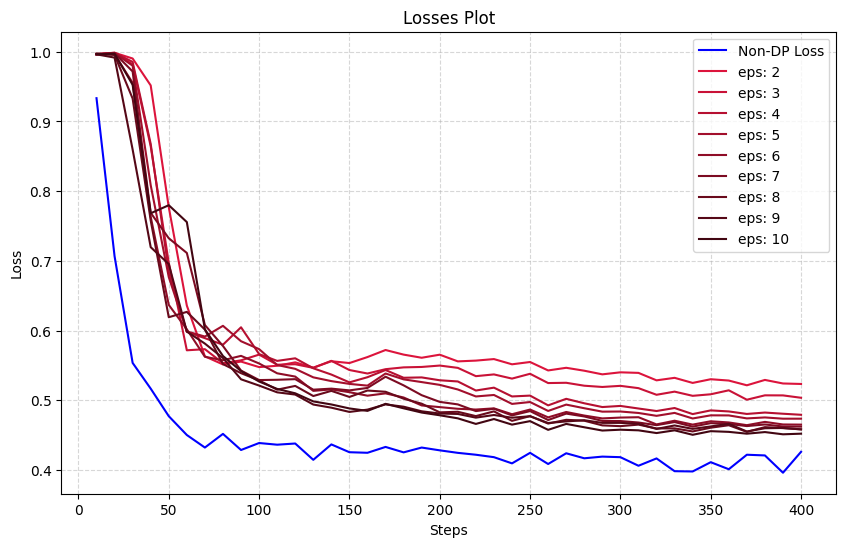

In [31]:
eps = [2, 3, 4, 5, 6, 7, 8, 9, 10]
# eps = [6, 7, 8, 9, 10]

import matplotlib.colors as mcolors
base_color = mcolors.to_rgb("crimson")

# Generate fading colors
n = len(eps)
colors = [
    (base_color[0] * (0.3 + 0.7 * (i / (n - 1))),
     base_color[1] * (0.3 + 0.7 * (i / (n - 1))),
     base_color[2] * (0.3 + 0.7 * (i / (n - 1))))
    for i in range(n)
]
colors = colors[::-1]

non_dp = np.genfromtxt('../exp/wilt/ddpm_cb_best/loss.csv', delimiter=',', names=True)
non_dp_df = pd.DataFrame(non_dp, columns = ['step','mloss','gloss', 'loss'])
non_dp_df = non_dp_df.set_index('step')






# plt.figure(figsize=(16, 8), dpi=150) 
plt.figure(figsize=(10, 6))
plt.plot(non_dp_df.index, non_dp_df['loss'], label='Non-DP Loss', color='blue')

for e in eps:
    dp = np.genfromtxt('../exp/wilt/wilt_dp_eps_' + str(e) + '_best/loss.csv', delimiter=',', names=True)
    dp_df = pd.DataFrame(dp, columns = ['step','mloss','gloss', 'loss'])
    dp_df = dp_df.set_index('step')
    plt.plot(dp_df.index, dp_df['loss'], label='eps: '+str(e), color=colors[eps.index(e)])
# plt.gca().invert_yaxis()

plt.grid(True, linestyle="--", alpha=0.5)
plt.title('Losses Plot') 
plt.xlabel('Steps') 
plt.ylabel('Loss') 
  
# adding legend. 
plt.legend() 

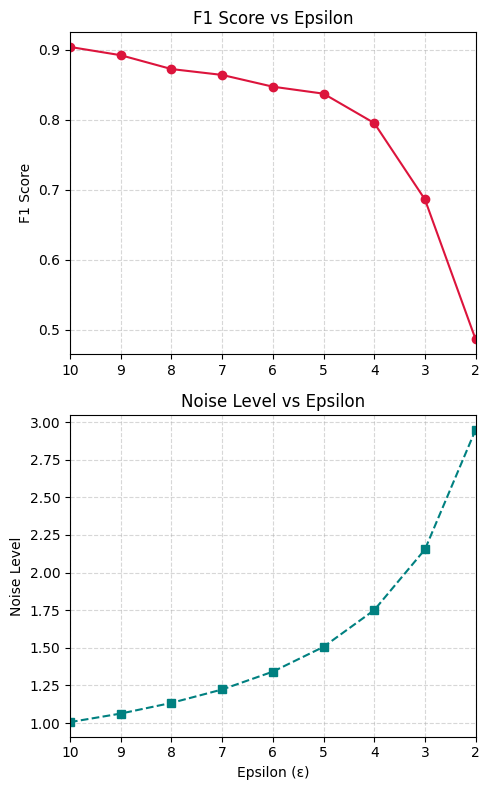

In [43]:
eps = [2, 3, 4, 5, 6, 7, 8, 9, 10]

f1 = [0.4862, 0.6863, 0.7955, 0.8375, 0.8475, 0.8643, 0.8727, 0.8925, 0.9043]
noise = [2.94921875 , 2.1533203125, 1.75048828125 , 1.50634765625, 1.341552734375, 1.22314453125, 1.134033203125, 1.063232421875, 1.0064697265625]


# Create subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(5, 8))

# --- F1 Plot ---
ax1.plot(eps, f1, 'o-', color='crimson')
ax2.set_xlabel("Epsilon (ε)")
ax1.set_ylabel("F1 Score")
ax1.set_title("F1 Score vs Epsilon")
ax1.grid(True, linestyle="--", alpha=0.5)

# --- Noise Plot ---
ax2.plot(eps, noise, 's--', color='teal')
ax2.set_xlabel("Epsilon (ε)")
ax2.set_ylabel("Noise Level")
ax2.set_title("Noise Level vs Epsilon")
ax2.grid(True, linestyle="--", alpha=0.5)

# Invert x-axis so that 10 is left and 2 is right
ax1.set_xlim(10, 2)
ax2.set_xlim(10, 2)

plt.tight_layout()
plt.show()

## two plots in one

# f1_norm = f1
# noise_norm = noise

# # Plot
# plt.figure(figsize=(8, 6))
# plt.plot(eps, f1_norm, 'o-', color='crimson', label='F1 score')
# plt.plot(eps, noise_norm, 's--', color='teal', label='Noise level')

# plt.xlabel("Epsilon (ε)")
# plt.ylabel("Normalized value")
# plt.gca().invert_xaxis()  # Invert so 10 is on the left (lowest privacy)
# plt.grid(True, linestyle="--", alpha=0.5)
# plt.legend()
# plt.tight_layout()
# plt.show()

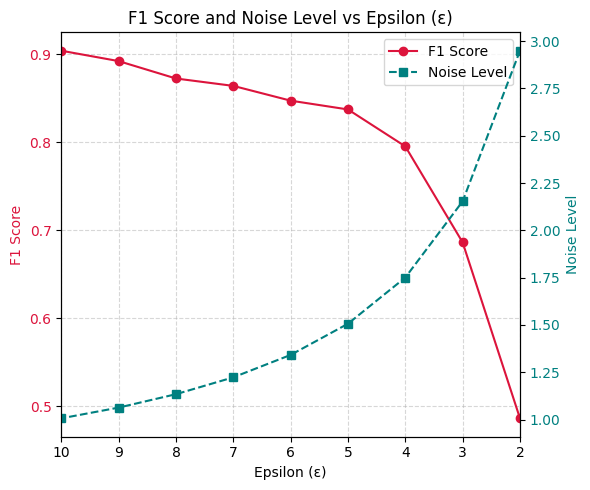

In [44]:
fig, ax1 = plt.subplots(figsize=(6, 5))

# Plot F1 score on left y-axis
ax1.plot(eps, f1, 'o-', color='crimson', label='F1 Score')
ax1.set_xlabel("Epsilon (ε)")
ax1.set_ylabel("F1 Score", color='crimson')
ax1.tick_params(axis='y', labelcolor='crimson')
ax1.set_xlim(10, 2)  # invert x-axis
ax1.grid(True, linestyle="--", alpha=0.5)

# Create second y-axis for noise
ax2 = ax1.twinx()
ax2.plot(eps, noise, 's--', color='teal', label='Noise Level')
ax2.set_ylabel("Noise Level", color='teal')
ax2.tick_params(axis='y', labelcolor='teal')

# Add a combined legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='best')

plt.title("F1 Score and Noise Level vs Epsilon (ε)")
plt.tight_layout()
plt.show()

In [ ]:
eps = [2, 3, 4, 5, 6, 7, 8, 9, 10]

